# Ноутбук посвящен обучению базового MLP на датасете FreeSolv 

https://github.com/MobleyLab/FreeSolv

In [1]:
import pickle
import pandas as pd

dataset_path = 'database.pickle'

with open(dataset_path, 'rb') as file:
    data = pickle.load(file)

data

{'mobley_5708811': {'calc_h': np.float64(-22.379095928698007),
  'd_charging': 0.018,
  'PubChemID': 3030,
  'iupac': 'dicamba',
  'expt_h_reference': 'Not available',
  'groups': ['alkyl aryl ether',
   'aryl chloride',
   'carboxylic acid',
   'aromatic'],
  'h_solv': np.float64(-23.066887301608755),
  'smiles': 'COc1c(ccc(c1C(=O)O)Cl)Cl',
  'd_calc_h': 0.7100932555128079,
  'calc_s (cal/mol.K)': np.float64(-46.020781246681224),
  'calc_vdw': 0.535,
  'notes': ['Experimental uncertainty not presently available, so assigned a default value.'],
  'expt_reference': '10.1021/jp806724u',
  'd_h_conf': np.float64(0.05619776379206755),
  'd_expt_s (cal/K.mol)': 'Not available',
  'd_calc': 0.038,
  'expt': -9.86,
  'calc_charging': -9.193,
  'd_expt': 1.93,
  'd_vdw': 0.033,
  'h_conf': np.float64(0.68356777693911),
  'd_expt_h': 'Not available',
  'expt_s (cal/K.mol)': 'Not available',
  'd_calc_s (cal/mol.K)': np.float64(2.3850722672114695),
  'expt_h': 'Not available',
  'calc': -8.658,


## Фильтруем интесующие нас значения из датасета 
Нас интересуют лишь два ключа: **smiles** и **h_solv**. 

**smiles** - текстовое представление молекулы - 
будем использовать для дальнейшего рассчета дескрипторов RDKIT. 

**h_solv** - энтальпия сольватации 
(таргет)

In [2]:
dataset = {
    'smiles': [value['smiles'] for value in data.values()],
    'h_solv': [value['h_solv'] for value in data.values()]
}

In [3]:
df = pd.DataFrame.from_dict(dataset)
df.head()

,smiles,h_solv
0,COc1c(ccc(c1C(=O)O)Cl)Cl,-23.066887
1,CCOP(=S)(OCC)SCSCC,-23.602447
2,c1ccc(c(c1)O)F,-14.246424
3,c1c(c(c(c(c1Cl)Cl)Cl)Cl)c2c(cc(c(c2Cl)Cl)Cl)Cl,-14.603798
4,CC(C)C,-7.126749


## Делаем sanity check

In [4]:
df['h_solv'].isna().sum()
df['smiles'].isna().sum()

np.int64(0)

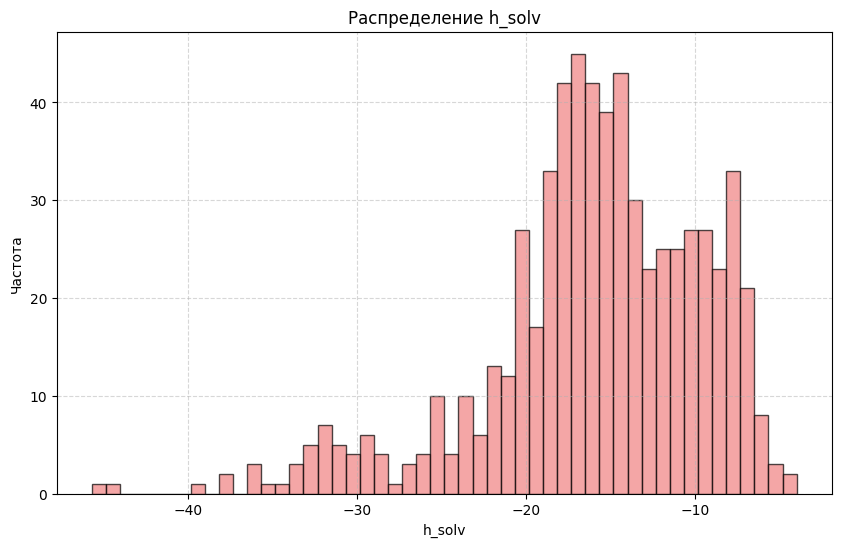

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['h_solv'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Распределение h_solv')
plt.xlabel('h_solv')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Рассчет дескрипторов

In [6]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

descriptor_list = Descriptors.descList  

def compute_all_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {name: func(mol) for name, func in descriptor_list}

print("Расчёт дескрипторов...")
desc_df = df['smiles'].apply(lambda x: pd.Series(compute_all_descriptors(x)))

print(f"Посчитано {len(descriptor_list)} дескрипторов.")
print(f"Новые столбцы: {list(desc_df.columns)[:5]}...")

Расчёт дескрипторов...
Посчитано 217 дескрипторов.
Новые столбцы: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed']...


In [7]:
desc_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,10.730617,10.730617,0.084877,-1.162639,0.834381,9.769231,221.039,214.991,219.969399,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.469779,5.469779,0.639950,-2.019869,0.374797,11.923077,260.386,243.250,260.012829,80.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,12.068704,12.068704,0.298611,-0.576389,0.539215,9.125000,112.103,107.063,112.032443,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6.176121,6.176121,0.105592,0.105592,0.314328,11.000000,429.772,427.756,425.766472,106.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.166667,2.166667,0.833333,0.833333,0.397118,9.000000,58.124,48.044,58.078250,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,11.838371,11.838371,0.334491,-4.738310,0.593359,11.583333,180.085,177.061,180.014662,66.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
638,11.975556,11.975556,0.089259,-0.330741,0.539215,9.125000,112.103,107.063,112.032443,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
639,10.158704,10.158704,0.152778,-0.395833,0.437912,9.300000,137.138,130.082,137.047678,52.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
640,8.698025,8.698025,0.244815,0.244815,0.567108,9.125000,128.558,123.518,128.002892,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Нам не стоит использовать все дескрипторы бездумно 
поэтому далее мы фильтруем константные и около констатные 
дескрипторы (чья дисперсия около нулевая) 

In [8]:
# Рассчитываем дисперсию для каждого признака
variances = desc_df.var()
# Находим признаки с нулевой дисперсией (абсолютно постоянные)
constant_features = variances[variances == 0].index.tolist()
print(f"Найдено постоянных признаков: {len(constant_features)}")
if constant_features:
    print(f"Список: {constant_features}")

Найдено постоянных признаков: 32
Список: ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'EState_VSA11', 'NumSpiroAtoms', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_N_O', 'fr_alkyl_carbamate', 'fr_amidine', 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_furan', 'fr_guanido', 'fr_hdrzone', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_lactone', 'fr_nitroso', 'fr_oxazole', 'fr_prisulfonamd', 'fr_quatN', 'fr_sulfonamd', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan']


In [9]:
def near_constant_features(df, threshold=0.95):
    """Находит признаки, где доля самого частого значения превышает порог."""
    near_constant = []
    for col in df.columns:
        most_common_freq = df[col].value_counts(normalize=True).iloc[0]
        if most_common_freq >= threshold:
            near_constant.append((col, most_common_freq))
    return near_constant

near_constant = near_constant_features(desc_df, threshold=0.95)
print(f"\nПризнаки, где >95% значений одинаковы: {len(near_constant)}")
if near_constant:
    for feat, freq in near_constant[:5]: 
        print(f"  {feat}: {freq:.2%} значений = {desc_df[feat].mode().iloc[0]}")


Признаки, где >95% значений одинаковы: 72
  NumRadicalElectrons: 100.00% значений = 0.0
  SMR_VSA2: 98.13% значений = 0.0
  SMR_VSA8: 100.00% значений = 0.0
  SlogP_VSA9: 100.00% значений = 0.0
  EState_VSA11: 100.00% значений = 0.0


In [10]:
constant_columns_names = [column[0] for column in near_constant]
cleaned_desc_df = desc_df.drop(constant_columns_names, axis=1)

In [11]:
cleaned_desc_df # получаем датафрейм с фичами

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_bicyclic,fr_ester,fr_ether,fr_halogen,fr_ketone,fr_methoxy,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_unbrch_alkane
0,10.730617,10.730617,0.084877,-1.162639,0.834381,9.769231,221.039,214.991,219.969399,70.0,...,0.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0
1,5.469779,5.469779,0.639950,-2.019869,0.374797,11.923077,260.386,243.250,260.012829,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,12.068704,12.068704,0.298611,-0.576389,0.539215,9.125000,112.103,107.063,112.032443,42.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
3,6.176121,6.176121,0.105592,0.105592,0.314328,11.000000,429.772,427.756,425.766472,106.0,...,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.166667,2.166667,0.833333,0.833333,0.397118,9.000000,58.124,48.044,58.078250,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,11.838371,11.838371,0.334491,-4.738310,0.593359,11.583333,180.085,177.061,180.014662,66.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
638,11.975556,11.975556,0.089259,-0.330741,0.539215,9.125000,112.103,107.063,112.032443,42.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
639,10.158704,10.158704,0.152778,-0.395833,0.437912,9.300000,137.138,130.082,137.047678,52.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
640,8.698025,8.698025,0.244815,0.244815,0.567108,9.125000,128.558,123.518,128.002892,42.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


## Создаем итоговый датафрейм

In [12]:
final_df = pd.concat((df,cleaned_desc_df),axis=1) # объединяем с таргетом и колонкой smiles
final_df

,smiles,h_solv,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_bicyclic,fr_ester,fr_ether,fr_halogen,fr_ketone,fr_methoxy,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_unbrch_alkane
0,COc1c(ccc(c1C(=O)O)Cl)Cl,-23.066887,10.730617,10.730617,0.084877,-1.162639,0.834381,9.769231,221.039,214.991,...,0.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0
1,CCOP(=S)(OCC)SCSCC,-23.602447,5.469779,5.469779,0.639950,-2.019869,0.374797,11.923077,260.386,243.250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,c1ccc(c(c1)O)F,-14.246424,12.068704,12.068704,0.298611,-0.576389,0.539215,9.125000,112.103,107.063,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
3,c1c(c(c(c(c1Cl)Cl)Cl)Cl)c2c(cc(c(c2Cl)Cl)Cl)Cl,-14.603798,6.176121,6.176121,0.105592,0.105592,0.314328,11.000000,429.772,427.756,...,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CC(C)C,-7.126749,2.166667,2.166667,0.833333,0.833333,0.397118,9.000000,58.124,48.044,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,c1c(c(=O)[nH]c(=O)[nH]1)C(F)(F)F,-31.250372,11.838371,11.838371,0.334491,-4.738310,0.593359,11.583333,180.085,177.061,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
638,c1cc(ccc1O)F,-15.692737,11.975556,11.975556,0.089259,-0.330741,0.539215,9.125000,112.103,107.063,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
639,Cc1cccc(c1)[N+](=O)[O-],-15.355164,10.158704,10.158704,0.152778,-0.395833,0.437912,9.300000,137.138,130.082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
640,c1cc(ccc1O)Cl,-15.692474,8.698025,8.698025,0.244815,0.244815,0.567108,9.125000,128.558,123.518,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


## Начинаем подготовку датасета для обучения

In [13]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Подготовка данных
target = 'h_solv'
feature_columns = [col for col in final_df.columns if col != target and col != 'smiles']  

X = final_df[feature_columns].values
y = final_df[target].values

# Разделение на train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Первые 20 фичей: \n {X_train[0][:20]}\n')
print(f'Таргет: \n {y_train[0]}')

Первые 20 фичей: 
 [ 3.28472222e+00  3.28472222e+00  1.25000000e+00  1.25000000e+00
  4.57636228e-01  2.40000000e+01  8.51500000e+01  7.40620000e+01
  8.50891494e+01  3.60000000e+01 -4.89114001e-03 -3.16732581e-01
  3.16732581e-01  4.89114001e-03  8.33333333e-01  1.50000000e+00
  1.66666667e+00  1.48519096e+01  1.01695466e+01  1.93163566e+00]

Таргет: 
 -16.92583712378366


In [14]:
from sklearn.preprocessing import StandardScaler

# Нормализация
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

print(f'Первые 20 нормализованных фичей: \n {X_train_scaled[0][:20]}\n')

Первые 20 нормализованных фичей: 
 [-1.08748893 -1.08748893  0.99654995  0.84015916 -0.34300422  1.93966546
 -0.7420185  -0.765433   -0.74256176 -0.60645787 -0.92972016 -0.21674831
  0.16010596 -1.11258648 -1.07591431 -0.43559414 -0.57748007 -0.49389817
 -0.26036064  0.13253365]



## Создание Dataset и DataLoader

In [15]:
from torch.utils.data import Dataset, DataLoader

class SolubilityDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # Добавляем размерность (batch, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SolubilityDataset(X_train_scaled, y_train)
val_dataset = SolubilityDataset(X_val_scaled, y_val)

batch_size = 128
shuffle = True

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle, drop_last=True)# Нужно чтобы мы смогли посчитать батч-норм
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [16]:
train_dataset[0]  # Посмотрим на то, что лежит внутри dataset

(tensor([-1.0875e+00, -1.0875e+00,  9.9655e-01,  8.4016e-01, -3.4300e-01,
          1.9397e+00, -7.4202e-01, -7.6543e-01, -7.4256e-01, -6.0646e-01,
         -9.2972e-01, -2.1675e-01,  1.6011e-01, -1.1126e+00, -1.0759e+00,
         -4.3559e-01, -5.7748e-01, -4.9390e-01, -2.6036e-01,  1.3253e-01,
         -6.6031e-01, -1.0058e-01, -1.1034e+00, -7.7949e-01, -5.8413e-02,
         -1.2513e-04, -1.3115e+00, -8.1725e-01, -8.2909e-01, -5.6551e-01,
         -6.9789e-01, -5.6363e-01, -1.0386e-01, -3.2413e-01, -1.2051e-01,
         -3.5737e-01,  1.2072e-01, -1.4629e-01,  2.5157e-01, -2.8250e-02,
          5.9688e-01, -1.7681e-01, -9.2978e-01, -5.2940e-01, -7.7021e-02,
         -6.7444e-01,  3.8687e-01, -5.0839e-01, -2.7667e-01, -2.3837e-01,
         -3.0080e-01, -4.2668e-01, -5.2951e-01, -2.6614e-01, -2.9258e-01,
         -3.0708e-01, -7.1621e-01,  1.3339e+00, -8.1131e-01, -5.6894e-01,
         -8.1600e-01, -6.3912e-01,  1.7621e+00, -3.3538e-01,  2.8840e-01,
          1.1709e+00, -8.9771e-01, -4.

In [17]:
next(iter(train_loader)) # Посмотрим на то, что лежит внутри dataloader

[tensor([[ 1.1173,  1.1173, -0.5534,  ..., -0.2908, -0.2868,  5.0253],
         [-0.2226, -0.2226, -0.5756,  ..., -0.2908, -0.2868, -0.3530],
         [ 1.0035,  1.0035, -0.6032,  ..., -0.2908, -0.2868,  0.5434],
         ...,
         [-1.4149, -1.4149,  0.9273,  ..., -0.2908, -0.2868, -0.3530],
         [-1.3649, -1.3649,  0.6056,  ..., -0.2908, -0.2868, -0.3530],
         [-0.4751, -0.4751,  0.3429,  ..., -0.2908, -0.2868,  3.2326]]),
 tensor([[-17.4960],
         [-15.4080],
         [-15.0253],
         [-18.3188],
         [-11.1605],
         [-13.7686],
         [-16.8044],
         [-10.4774],
         [-31.7423],
         [ -7.1036],
         [-29.3947],
         [ -8.5599],
         [-18.4009],
         [ -9.6462],
         [-22.0451],
         [-25.4276],
         [-12.5421],
         [ -8.0605],
         [-18.8055],
         [-17.3875],
         [-17.6635],
         [-22.1822],
         [-18.3880],
         [-11.4925],
         [-11.9948],
         [ -6.5464],
         [-1

In [18]:
print(next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape) 
# Проверим размерности - 

torch.Size([128, 145]) torch.Size([128, 1])


## Создадим модель как взрослые - через класс!

In [19]:
# Для ускорения вычислений - используем видеоядра
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f'Device - {device}')

# Создадим кастомную модель с новой архитектурой
class MLPModel(nn.Module):
    def __init__(self, input_dim):
        super(MLPModel, self).__init__()
        
        # Cкрытый слой
        self.fc = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.dropout1 = nn.Dropout(0.05)
        
        # Выходной слой
        self.out = nn.Linear(64, 1)
        
        # Функция активации - возьмем в этот раз Relu
        self.relu = nn.ReLU()

    def forward(self, x):
        # Слой 1: Linear -> BatchNorm -> ReLU -> Dropout
        x = self.fc(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        # Выход
        x = self.out(x)
        return x
    
input_dim = X_train_scaled.shape[1] # задаем размерность входа
model = MLPModel(input_dim).to(device) # Создаем инстанс модели - проверим ее архитекутуру
model

Device - mps


MLPModel(
  (fc): Linear(in_features=145, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout1): Dropout(p=0.05, inplace=False)
  (out): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)

## Обучение MLP

In [20]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 
num_epochs = 150

train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    # --- TRAIN ---
    model.train()
    epoch_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Переносим батч на устройство (GPU/CPU)
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item() * batch_X.size(0) # Умножаем на размер батча для среднего
    
    # Средний лосс за эпоху
    epoch_train_loss /= len(train_dataset)
    train_loss_history.append(epoch_train_loss)

    # --- VALIDATION ---
    model.eval()
    epoch_val_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.inference_mode():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            val_pred = model(batch_X)
            loss = criterion(val_pred, batch_y)
            
            epoch_val_loss += loss.item() * batch_X.size(0)
            
            # Сохраняем предсказания для метрик (возвращаем на CPU для sklearn)
            all_preds.extend(val_pred.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
            
    epoch_val_loss /= len(val_dataset)
    val_loss_history.append(epoch_val_loss)

    if (epoch + 1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {epoch_train_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}')

Epoch [25/150], Train Loss: 164.6791, Val Loss: 186.6160
Epoch [50/150], Train Loss: 61.2712, Val Loss: 69.4175
Epoch [75/150], Train Loss: 12.6707, Val Loss: 18.1928
Epoch [100/150], Train Loss: 2.1453, Val Loss: 6.8066
Epoch [125/150], Train Loss: 1.3460, Val Loss: 5.9620
Epoch [150/150], Train Loss: 1.6207, Val Loss: 6.4143


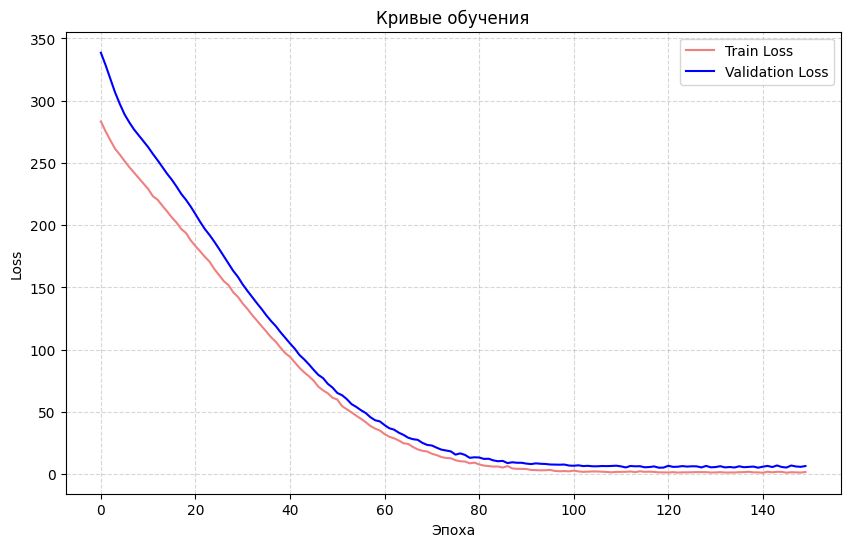

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, color='lightcoral', label = 'Train Loss')
plt.plot(val_loss_history, color='blue', label = 'Validation Loss')
plt.legend() 

plt.title('Кривые обучения')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [22]:
model.eval()
with torch.inference_mode():
    final_preds = []
    final_targets = []
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        pred = model(batch_X)
        final_preds.extend(pred.cpu().numpy())
        final_targets.extend(batch_y.cpu().numpy())

    r2 = r2_score(final_targets, final_preds)
    mae = mean_absolute_error(final_targets, final_preds)

    print("\n--- Итоговые метрики на валидации ---")
    print(f'R2 Score: {r2:.4f}')
    print(f'MAE: {mae:.4f}')


--- Итоговые метрики на валидации ---
R2 Score: 0.9014
MAE: 1.4712


## Теперь сравним обучение с XGBoost

In [ ]:
import xgboost as xgb

model = xgb.XGBRegressor(
    eval_metric='rmse'
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)

print("\n=== Результаты XGBoost на валидации  ===")
print(f"R²: {r2_score(y_val, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_val, y_pred):.4f}")